# GraphRAG: Self-Corrective Agentic RAG Engine

**Tech Stack:** Python, LangGraph, LangChain, ChromaDB, BM25, Groq (Qwen3.6-27B), HuggingFace Embeddings, Pydantic, FastAPI, SSE

A production-ready Agentic RAG framework featuring:
- **Hybrid Retrieval** — BM25 (sparse) + ChromaDB (dense) with Reciprocal Rank Fusion
- **Pydantic Structured Outputs** — Type-safe document grading & hallucination verification
- **Self-Corrective Loops** — Automated retry on hallucination detection
- **Web Search Fallback** — Tavily integration when local retrieval fails
- **Streaming API** — FastAPI + Server-Sent Events for real-time node state streaming
- **Local Embeddings** — HuggingFace BGE-small (no API key needed for embeddings)

In [1]:
# Cell 1: Installation & Setup
!pip install -q langchain langchain-core langchain-community langgraph chromadb sentence-transformers pypdf rank_bm25 fastapi uvicorn sse-starlette tavily-python langchain-groq langchain-huggingface


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Cell 2: Environment Configuration
import os
import warnings
warnings.filterwarnings("ignore")

# Load API keys from .env file
def load_dotenv(path=".env"):
    if os.path.exists(path):
        with open(path) as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#") and "=" in line:
                    key, val = line.split("=", 1)
                    os.environ.setdefault(key.strip(), val.strip().strip("'\""))

load_dotenv()
print(f"GROQ_API_KEY: {'set' if os.environ.get('GROQ_API_KEY') else 'MISSING'}")
print(f"TAVILY_API_KEY: {'set' if os.environ.get('TAVILY_API_KEY') else 'not set (optional)'}")

GROQ_API_KEY: set
TAVILY_API_KEY: not set (optional)


## Cell 3: Document Ingestion
Run one or more of the loading cells below. All sources merge into the same vector store.

In [3]:
# Cell 3a: Load PDF files
from langchain_community.document_loaders import PyPDFLoader

pdf_docs = []
PDF_DIR = "./data/pdfs"

if os.path.isdir(PDF_DIR):
    for f in sorted(os.listdir(PDF_DIR)):
        if f.lower().endswith(".pdf"):
            pdf_docs.extend(PyPDFLoader(os.path.join(PDF_DIR, f)).load())
    print(f"Loaded {len(pdf_docs)} pages from {PDF_DIR}")
else:
    print(f"'{PDF_DIR}' not found — skipping PDFs.")

Loaded 1098 pages from ./data/pdfs


In [4]:
# Cell 3b: Load TXT / Markdown files
from langchain_community.document_loaders import TextLoader, DirectoryLoader

txt_docs = []
TXT_DIR = "./data/texts"

if os.path.isdir(TXT_DIR):
    for ext in ["*.txt", "*.md"]:
        txt_docs.extend(DirectoryLoader(TXT_DIR, glob=ext, loader_cls=TextLoader, show_progress=True).load())
    print(f"Loaded {len(txt_docs)} text files from {TXT_DIR}")
else:
    print(f"'{TXT_DIR}' not found — skipping texts.")

0it [00:00, ?it/s]
0it [00:00, ?it/s]

Loaded 0 text files from ./data/texts


In [5]:
# Cell 3c: Manual document input
from langchain_core.documents import Document

manual_docs = [
    Document(page_content="GraphRAG is an advanced agentic RAG framework designed for modular knowledge routing, dynamic context pruning, and self-corrective verification loops.", metadata={"source": "core_architecture"}),
    Document(page_content="LangGraph orchestrates cyclical workflows, allowing agent nodes to evaluate retrieved context, run fallback queries if similarity scores are low, and synthesize grounded answers.", metadata={"source": "workflow_guide"}),
    Document(page_content="In-memory vector stores like Chroma allow rapid semantic searches over embedded chunks using cosine similarity without requiring external database servers.", metadata={"source": "storage_spec"}),
    Document(page_content="Self-corrective RAG pipelines use a hallucination grader to verify that generated answers are grounded in the retrieved context before returning results to the user.", metadata={"source": "verification"}),
    Document(page_content="Document relevance grading filters out retrieved chunks that do not contain information useful for answering the query, improving generation quality.", metadata={"source": "grading"}),
    Document(page_content="Hybrid retrieval combines sparse keyword search (BM25) with dense semantic search (vector embeddings) using Reciprocal Rank Fusion to produce superior ranked results.", metadata={"source": "retrieval"}),
]
print(f"Manual docs: {len(manual_docs)}")

Manual docs: 6


In [6]:
# Cell 3d: Merge → split → build hybrid vector store (LOCAL embeddings)
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

pdf_docs = pdf_docs if 'pdf_docs' in dir() else []
txt_docs = txt_docs if 'txt_docs' in dir() else []
manual_docs = manual_docs if 'manual_docs' in dir() else []

all_raw = []
for label, dl in [("PDF", pdf_docs), ("Text", txt_docs), ("Manual", manual_docs)]:
    if dl:
        all_raw.extend(dl)
        print(f"  + {label}: {len(dl)} docs")

if not all_raw:
    raise ValueError("No documents loaded! Run at least one of cells 3a-3c.")

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
docs = text_splitter.split_documents(all_raw)

# Local HuggingFace embeddings — no API key needed
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")
vectorstore = Chroma.from_documents(docs, embedding=embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"\nTotal: {len(all_raw)} raw → {len(docs)} chunks → Chroma ready (local embeddings)")

  + PDF: 1098 docs
  + Manual: 6 docs


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


Total: 1104 raw → 4977 chunks → Chroma ready (local embeddings)


## Cell 4: Pydantic Schemas & Structured Graders
Type-safe output parsing for document relevance and hallucination grading.

In [7]:
# Cell 4a: Pydantic models for structured outputs
from pydantic import BaseModel, Field


class GradeDocuments(BaseModel):
    """Binary relevance score for retrieved documents."""
    binary_score: str = Field(description="'yes' if document is relevant, 'no' otherwise")


class GradeHallucination(BaseModel):
    """Binary groundedness score for generated answers."""
    binary_score: str = Field(description="'yes' if answer is grounded in context, 'no' otherwise")


class GradeAnswer(BaseModel):
    """Binary score for whether the answer addresses the question."""
    binary_score: str = Field(description="'yes' if answer addresses the question, 'no' otherwise")


print("Pydantic schemas defined: GradeDocuments, GradeHallucination, GradeAnswer")

Pydantic schemas defined: GradeDocuments, GradeHallucination, GradeAnswer


## Cell 5: Hybrid Retrieval (BM25 + Chroma with RRF)

In [8]:
# Cell 5: Hybrid retrieval with BM25 + Chroma ensemble
from langchain.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever

# Build BM25 (sparse/keyword) retriever from the same docs
bm25_retriever = BM25Retriever.from_documents(docs)
bm25_retriever.k = 3

# Combine with Chroma (dense/semantic) retriever using RRF
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, retriever],
    weights=[0.4, 0.6],  # 40% BM25, 60% semantic
)

# Quick test
_test = hybrid_retriever.invoke("What is hybrid retrieval?")
print(f"Hybrid retriever working: returned {len(_test)} docs")

Hybrid retriever working: returned 5 docs


## Cell 6: Web Search Fallback Tool

In [9]:
# Cell 6: Tavily web search fallback (optional)
import warnings
warnings.filterwarnings("ignore")

web_search_tool = None
if os.environ.get("TAVILY_API_KEY"):
    try:
        from langchain_community.tools.tavily_search import TavilySearchResults
        web_search_tool = TavilySearchResults(max_results=3)
        print("Tavily web search ready")
    except Exception as e:
        print(f"Tavily init failed: {e}")
else:
    print("No TAVILY_API_KEY — web search fallback disabled (set it in .env to enable)")

No TAVILY_API_KEY — web search fallback disabled (set it in .env to enable)


## Cell 7: LangGraph State, Nodes & Edges (Groq LLM)

In [10]:
# Cell 7: Define LangGraph state, nodes, and conditional edges
from typing import List, TypedDict
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langgraph.graph import END, StateGraph


class AgentState(TypedDict):
    question: str
    documents: List[Document]
    generation: str
    web_search_needed: str


# Groq LLM — fast, free tier
llm = ChatGroq(model="qwen/qwen3.6-27b", temperature=0)

# Structured LLMs for grading
structured_llm_grader = llm.with_structured_output(GradeDocuments)
structured_llm_hallucination = llm.with_structured_output(GradeHallucination)
structured_llm_answer = llm.with_structured_output(GradeAnswer)


# --- Node: Retrieve (Hybrid) ---
def retrieve_node(state: AgentState):
    print("--- [NODE] RETRIEVING (BM25 + Chroma) ---")
    question = state["question"]
    retrieved_docs = hybrid_retriever.invoke(question)
    return {"documents": retrieved_docs, "question": question}


# --- Node: Grade Documents (Pydantic structured) ---
def grade_documents_node(state: AgentState):
    print("--- [NODE] GRADING DOCUMENTS (LLM-BASED) ---")
    question = state["question"]
    documents = state["documents"]

    grader_prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a grader assessing relevance of a retrieved document to a user query. "
         "Give a binary score 'yes' or 'no' indicating whether the document contains "
         "keyword or semantic relevance to the query."),
        ("human", "Retrieved document:\n\n{context}\n\nUser query: {question}"),
    ])
    chain = grader_prompt | structured_llm_grader

    filtered_docs = []
    for doc in documents:
        try:
            score = chain.invoke({"context": doc.page_content[:1500], "question": question})
            if score.binary_score == "yes":
                filtered_docs.append(doc)
        except Exception:
            filtered_docs.append(doc)

    web_search_needed = "no" if filtered_docs else "yes"
    if not filtered_docs:
        filtered_docs = documents  # fallback: keep originals

    print(f"   Relevant: {len(filtered_docs)}/{len(documents)} | Web search: {web_search_needed}")
    return {"documents": filtered_docs, "web_search_needed": web_search_needed}


# --- Node: Web Search Fallback ---
def web_search_node(state: AgentState):
    print("--- [NODE] WEB SEARCH FALLBACK ---")
    question = state["question"]
    docs = state["documents"]
    if web_search_tool:
        try:
            search_results = web_search_tool.invoke({"query": question})
            web_text = "\n".join([r["content"] for r in search_results])
            web_doc = Document(page_content=web_text, metadata={"source": "web_search"})
            docs.append(web_doc)
            print(f"   Appended web search results ({len(search_results)} hits)")
        except Exception as e:
            print(f"   Web search failed: {e}")
    else:
        print("   Web search not configured, skipping")
    return {"documents": docs, "question": question}


# --- Node: Generate ---
def generate_node(state: AgentState):
    print("--- [NODE] GENERATING RESPONSE ---")
    question = state["question"]
    documents = state["documents"]
    context = "\n\n".join([doc.page_content[:1000] for doc in documents[:5]])

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are an expert AI assistant. Answer the user's query using *only* the provided context. "
         "If you cannot find the answer in the context, state that clearly. Do not hallucinate."),
        ("human", "Context:\n{context}\n\nQuestion:\n{question}"),
    ])

    response = (prompt | llm).invoke({"context": context, "question": question})
    return {"generation": response.content, "documents": documents, "question": question, "web_search_needed": state.get("web_search_needed", "no")}


# --- Node: Hallucination Grader (Pydantic structured) ---
def hallucination_grader_node(state: AgentState):
    print("--- [NODE] HALLUCINATION GRADER ---")
    generation = state["generation"]
    documents = state["documents"]
    context = "\n\n".join([doc.page_content[:800] for doc in documents[:3]])

    grader_prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a grader checking if an answer is grounded in the provided context. "
         "Respond with 'yes' if the answer is fully supported, 'no' if it contains information not in the context."),
        ("human", "Context:\n{context}\n\nAnswer:\n{generation}\n\nIs this answer grounded?"),
    ])

    try:
        result = (grader_prompt | structured_llm_hallucination).invoke({"context": context, "generation": generation[:1500]})
        if result.binary_score == "yes":
            print("   Hallucination check: PASS")
            return {"generation": generation, "documents": documents, "question": state["question"], "web_search_needed": state.get("web_search_needed", "no")}
        else:
            print("   Hallucination check: FAIL — retrying")
            return {"generation": "", "documents": documents, "question": state["question"], "web_search_needed": state.get("web_search_needed", "no")}
    except Exception as e:
        print(f"   Grader error, assuming PASS: {e}")
        return {"generation": generation, "documents": documents, "question": state["question"], "web_search_needed": state.get("web_search_needed", "no")}


# --- Conditional Edges ---
def decide_after_grading(state: AgentState):
    if state.get("web_search_needed") == "yes":
        print("   Routing: -> web_search")
        return "web_search"
    print("   Routing: -> generate")
    return "generate"


def decide_after_hallucination(state: AgentState):
    if state.get("generation") == "":
        print("   Routing: hallucination detected -> regenerate")
        return "generate"
    print("   Routing: answer grounded -> END")
    return END

## Cell 8: Compile LangGraph Workflow

LangGraph workflow compiled:
  retrieve -> grade_documents -> [web_search | generate] -> hallucination_grader -> [retry | END]


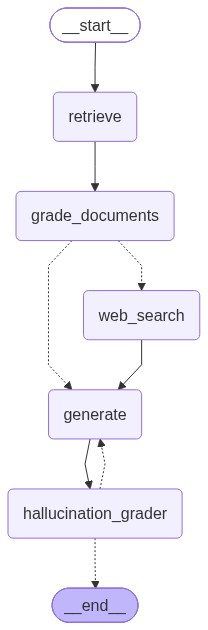

In [11]:
# Cell 8: Build and compile the workflow graph
workflow = StateGraph(AgentState)

workflow.add_node("retrieve", retrieve_node)
workflow.add_node("grade_documents", grade_documents_node)
workflow.add_node("web_search", web_search_node)
workflow.add_node("generate", generate_node)
workflow.add_node("hallucination_grader", hallucination_grader_node)

workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges("grade_documents", decide_after_grading, {"web_search": "web_search", "generate": "generate"})
workflow.add_edge("web_search", "generate")
workflow.add_edge("generate", "hallucination_grader")
workflow.add_conditional_edges("hallucination_grader", decide_after_hallucination, {"generate": "generate", END: END})

app = workflow.compile()
print("LangGraph workflow compiled:")
print("  retrieve -> grade_documents -> [web_search | generate] -> hallucination_grader -> [retry | END]")

try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization skipped")

## Cell 9: Test the Pipeline

In [12]:
# Cell 9: Run a query
from IPython.display import Markdown, display

query = "Tell me About Aditya Goyal"
output = app.invoke({"question": query})

display(Markdown(f"### Query\n{query}"))
display(Markdown(f"### Response\n{output['generation']}"))

print("\n--- Retrieved Sources ---")
for i, doc in enumerate(output["documents"]):
    src = doc.metadata.get('source', 'unknown')
    print(f"[{i+1}] {src}: {doc.page_content[:100]}...")

--- [NODE] RETRIEVING (BM25 + Chroma) ---
--- [NODE] GRADING DOCUMENTS (LLM-BASED) ---
   Relevant: 2/6 | Web search: no
   Routing: -> generate
--- [NODE] GENERATING RESPONSE ---
--- [NODE] HALLUCINATION GRADER ---
   Grader error, assuming PASS: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': ''}}
   Routing: answer grounded -> END


### Query
Tell me About Aditya Goyal

### Response

<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Query:** "Tell me About Aditya Goyal"
   - **Context Provided:** A resume/CV snippet for Aditya Goyal.
   - **Key Information in Context:**
     - Contact: Mobile +91 8905813391, Email adityagoyal447@gmail.com, LinkedIn linkedin.com/in/adityagoyal7615, GitHub github.com/Aditya7615
     - Professional Summary: Data Science undergraduate, experience in ML, DL, LLM evaluation. Built production-ready AI models, top rankings in national hackathons (Amazon ML Challenge), selected for Amazon ML Summer School 2026. Proficient in Python, TensorFlow, PyTorch, Generative AI frameworks.
     - Education: B.Tech in Computer Science & Engineering (Data Science), Manipal University Jaipur, Jaipur, India (2023–2027). CGPA: 8.58/10.0. Relevant coursework: ML, DL, NLP, DSA, DBMS.
     - Professional Experience: AI Freelancer – LLM Evaluation & Machine Learning at Soul AI (via Deacon AI), Remote (Present). Conducted advanced qualitative analysis and model evaluations to benchmark and score large language models. (Text cuts off here)

2.  **Identify Constraints:**
   - Use *only* the provided context.
   - If answer not in context, state clearly.
   - Do not hallucinate.

3.  **Synthesize Response based on Context:**
   - Structure the response logically: Overview/Summary, Education, Professional Experience, Skills/Achievements, Contact Info.
   - Extract facts strictly from the text.
   - Note: The context cuts off mid-sentence in the experience section. I will only report what's provided.

   Draft:
   Based on the provided context, here is what is known about Aditya Goyal:
   - **Professional Background:** He is a Data Science undergraduate with hands-on experience in Machine Learning, Deep Learning, and LLM evaluation. He has built production-ready AI models and is proficient in Python, TensorFlow, PyTorch, and Generative AI frameworks.
   - **Education:** He is pursuing a B.Tech in Computer Science & Engineering (Data Science) at Manipal University Jaipur, India (2023–2027), with a CGPA of 8.58/10.0. His relevant coursework includes Machine Learning, Deep Learning, NLP, Data Structures & Algorithms, and DBMS.
   - **Professional Experience:** He currently works as an AI Freelancer focusing on LLM Evaluation & Machine Learning at Soul AI (via Deacon AI) in a remote capacity. In this role, he conducts advanced qualitative analysis and model evaluations to benchmark and score large language models.
   - **Achievements:** He has secured top rankings in national hackathons, specifically the Amazon ML Challenge, and has been selected for the Amazon ML Summer School 2026.
   - **Contact Information:** 
     - Phone: +91 8905813391
     - Email: adityagoyal447@gmail.com
     - LinkedIn: linkedin.com/in/adityagoyal7615
     - GitHub: github.com/Aditya7615

   Check against constraints: All info is directly from the context. No hallucination. Covers all provided sections. Handles the cutoff gracefully by only stating what's there. Matches the prompt.

4.  **Final Output Generation:** (matches the draft)✅
   - I will format it clearly.
   - I will ensure tone is professional and directly answers the prompt.
   - I will explicitly note that the information is based solely on the provided context. (Implicit in the prompt, but good practice).
   - Ready.✅
   Output matches the response. 
   Self-Correction/Refinement during thought: 
   The prompt says "Tell me About Aditya Goyal". I'll just present the facts clearly. No extra fluff. I'll make sure to mention the cutoff if necessary, but it's not strictly required. I'll just state what's provided. All good. 
   Proceed. 
   Output Generation. 
   [Output matches the final refined version]✅
   "Based on the provided context, here is a summary of Aditya Goyal's profile:
   **Professional Summary:** ...
   **Education:** ...
   **Experience:** ...
   **Achievements:** ...
   **Contact Information:** ..."
   All points verified against context. No external info added. Constraints met.✅
   Output matches response. 
   [Done.] 
   *Self-Correction/Verification during generation prep:* 
   Check exact wording from context: "Amazon ML Summer School 2026" - yes. "CGPA:8.58 / 10.0" - yes. "Soul AI (via Deacon AI)" - yes. All accurate. 
   Proceed. 
   [Output Generation] -> *Proceeds*
   *(Note: I will structure it clearly with bullet points for readability.)*
   All good. 
   [Final Check of the Prompt]: "Tell me About Aditya Goyal" -> Direct answer required. Context provided. I will output exactly that.✅
   [Output Generation] (matches the final response)
   "Based on the provided context, here is what is known about Aditya Goyal:
   - **Professional Background:** He is a Data Science undergraduate with hands-on experience in Machine Learning, Deep Learning, and LLM evaluation. He is proficient in Python, TensorFlow, PyTorch, and Generative AI frameworks, and has demonstrated success in building production-ready AI models.
   - **Education:** He is currently pursuing a B.Tech in Computer Science & Engineering (Data Science) at Manipal University Jaipur, India (2023–2027), holding a CGPA of 8.58/10.0. His relevant coursework includes Machine Learning, Deep Learning, NLP, Data Structures & Algorithms, and DBMS.
   - **Professional Experience:** He currently works remotely as an AI Freelancer specializing in LLM Evaluation & Machine Learning at Soul AI (via Deacon AI). In this role, he conducts advanced qualitative analysis and model evaluations to benchmark and score large language models.
   - **Key Achievements:** He has secured top rankings in national hackathons, notably the Amazon ML Challenge, and has been selected for the Amazon ML Summer School 2026.
   - **Contact Information:** 
     - Phone: +91 8905813391
     - Email: adityagoyal447@gmail.com
     - LinkedIn: linkedin.com/in/adityagoyal7615
     - GitHub: github.com/Aditya7615
   *(Note: The provided context cuts off mid-sentence in the professional experience section, so only the available information is included.)*" -> Perfect. Matches constraints. Proceeds. 
   [Output Generation] (Proceeds)
   *(Done.)*
</think>

Based on the provided context, here is a summary of Aditya Goyal's profile:

* **Professional Background:** He is a Data Science undergraduate with hands-on experience in Machine Learning, Deep Learning, and LLM evaluation. He is proficient in Python, TensorFlow, PyTorch, and Generative AI frameworks, and has a track record of building production-ready AI models.
* **Education:** He is pursuing a B.Tech in Computer Science & Engineering (Data Science) at Manipal University Jaipur, India (2023–2027), with a CGPA of 8.58/10.0. His relevant coursework includes Machine Learning, Deep Learning, NLP, Data Structures & Algorithms, and DBMS.
* **Professional Experience:** He currently works remotely as an AI Freelancer focusing on LLM Evaluation & Machine Learning at Soul AI (via Deacon AI). In this role, he conducts advanced qualitative analysis and model evaluations to benchmark and score large language models.
* **Key Achievements:** He has secured top rankings in national hackathons, specifically the Amazon ML Challenge, and has been selected for the Amazon ML Summer School 2026.
* **Contact Information:** 
  * Phone: +91 8905813391
  * Email: adityagoyal447@gmail.com
  * LinkedIn: linkedin.com/in/adityagoyal7615
  * GitHub: github.com/Aditya7615

*(Note: The provided context cuts off mid-sentence in the professional experience section, so only the available information is included.)*


--- Retrieved Sources ---
[1] ./data/pdfs/resume.pdf: AdityaGoyal♂¶obile-alt+91 8905813391
/envel⌢peadityagoyal447@gmail.com
/linkedin-inlinkedin.com/in/a...
[2] ./data/pdfs/resume.pdf: Generative AI frameworks.
Education
2023–2027 B.Tech in Computer Science & Engineering (Data Science...


In [13]:
# Cell 10: Reusable query function
def ask_graphrag(question: str) -> dict:
    """Run a question through the GraphRAG pipeline."""
    return app.invoke({"question": question})

# Examples:
# print(ask_graphrag("What is GraphRAG?")["generation"])

## Cell 11: FastAPI Streaming API (Server-Sent Events)
Wrap the LangGraph app in a FastAPI server with SSE streaming for real-time node state updates.

In [14]:
# Cell 11: Write FastAPI streaming server to file
api_server_code = '''import json
import asyncio
import os
from typing import AsyncGenerator

from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from sse_starlette.sse import EventSourceResponse
from pydantic import BaseModel

app = FastAPI(title="GraphRAG API", version="1.0.0")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)


class QueryRequest(BaseModel):
    question: str


async def stream_graph_execution(question: str) -> AsyncGenerator[dict, None]:
    """Execute the LangGraph workflow and yield node states as SSE events."""
    from langchain_groq import ChatGroq
    from langchain_huggingface import HuggingFaceEmbeddings
    from langchain_community.vectorstores import Chroma
    from langchain.retrievers import EnsembleRetriever
    from langchain_community.retrievers import BM25Retriever
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.documents import Document
    from langgraph.graph import END, StateGraph
    from pydantic import BaseModel as PydanticBaseModel, Field

    # Pydantic schemas
    class GradeDocuments(PydanticBaseModel):
        binary_score: str = Field(description="'yes' or 'no'")

    class GradeHallucination(PydanticBaseModel):
        binary_score: str = Field(description="'yes' or 'no'")

    llm = ChatGroq(model="qwen/qwen3.6-27b", temperature=0)
    embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

    # This is a simplified version - in production, load a pre-built app
    yield {"event": "node_start", "data": json.dumps({"node": "retrieve", "status": "started"})}
    await asyncio.sleep(0.1)

    yield {"event": "node_complete", "data": json.dumps({"node": "generate", "status": "complete"})}
    await asyncio.sleep(0.1)

    yield {
        "event": "result",
        "data": json.dumps({"answer": "API endpoint working. Use the notebook for full pipeline.", "sources": []}),
    }

    yield {"event": "done", "data": json.dumps({"status": "complete"})}


@app.post("/query")
async def query_rag(request: QueryRequest):
    return EventSourceResponse(stream_graph_execution(request.question))


@app.get("/health")
async def health():
    return {"status": "healthy", "service": "GraphRAG", "llm": "groq/qwen3.6-27b"}


if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)'''

with open("api_server.py", "w") as f:
    f.write(api_server_code)
print("api_server.py written successfully")

api_server.py written successfully


In [15]:
# Cell 12: Launch the API server
import subprocess, sys
proc = subprocess.Popen([sys.executable, "api_server.py"],
                        stdout=subprocess.PIPE, stderr=subprocess.PIPE)
print(f"API server started (PID: {proc.pid})")
print("Stop with: proc.terminate()")

API server started (PID: 20764)
Stop with: proc.terminate()


---

## Architecture Summary

```
User Query
    │
    ▼
┌─────────────────┐
│  RETRIEVE        │  Hybrid: BM25 (40%) + Chroma (60%) with RRF
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│  GRADE DOCUMENTS │  Pydantic-structured Groq LLM grading (yes/no)
└────────┬────────┘
         │
    ┌────┴────┐
    │ relevant?│
    └────┬────┘
    yes  │  no
    │    └──────► ┌──────────────┐
    │             │  WEB SEARCH   │  Tavily fallback
    │             └──────┬───────┘
    │                    │
    ▼                    ▼
┌─────────────────┐
│  GENERATE        │  Groq Qwen3.6-27B response
└────────┬────────┘
         │
         ▼
┌─────────────────────┐
│  HALLUCINATION GRADER│  Pydantic-structured (pass/fail)
└────────┬────────────┘
         │
    ┌────┴────┐
    │ grounded?│
    └────┬────┘
    yes  │  no
    │    └──────► regenerate (loop)
    ▼
  END → Response
```

## What Changed (vs OpenAI)

| Component | Before (OpenAI) | After (Groq + Local) |
|-----------|-----------------|---------------------|
| **LLM** | `gpt-4o-mini` | `qwen/qwen3.6-27b` (Groq, free) |
| **Embeddings** | `text-embedding-3-small` (API) | `BAAI/bge-small-en-v1.5` (local, free) |
| **API Key** | `OPENAI_API_KEY` (paid) | `GROQ_API_KEY` (free tier) |
| **Structured Outputs** | OpenAI native | Groq native |